x 範圍： 0.0 → 2999.8
z 範圍： -209.86812999999998 → 97.89044000000001

=== Filtered Slope Angles ===
    From     To Slope Type  Angle (°)
0   1672   3172     Upward  44.303287
1   4346   5829     Upward  44.232663
2   6975   8521     Upward  42.896170
3   9697  11176     Upward  43.441748
4   3332   4186   Downward  59.654766
5   5989   6815   Downward  61.347684
6   8681   9537   Downward  60.225271
7  11336  12189   Downward  58.982268

=== Average Angle by Slope Type ===
Downward: 60.05°
Upward: 43.72°

=== Slope Angles vs Base Line ===
  Slope Type  Angle (°)  Angle w.r.t Base (°)
0     Upward  44.303287             41.153076
1     Upward  44.232663             42.045419
2     Upward  42.896170             39.773832
3     Upward  43.441748             41.564627
4   Downward  59.654766             56.589690
5   Downward  61.347684             57.909662
6   Downward  60.225271             57.573333
7   Downward  58.982268             55.753689


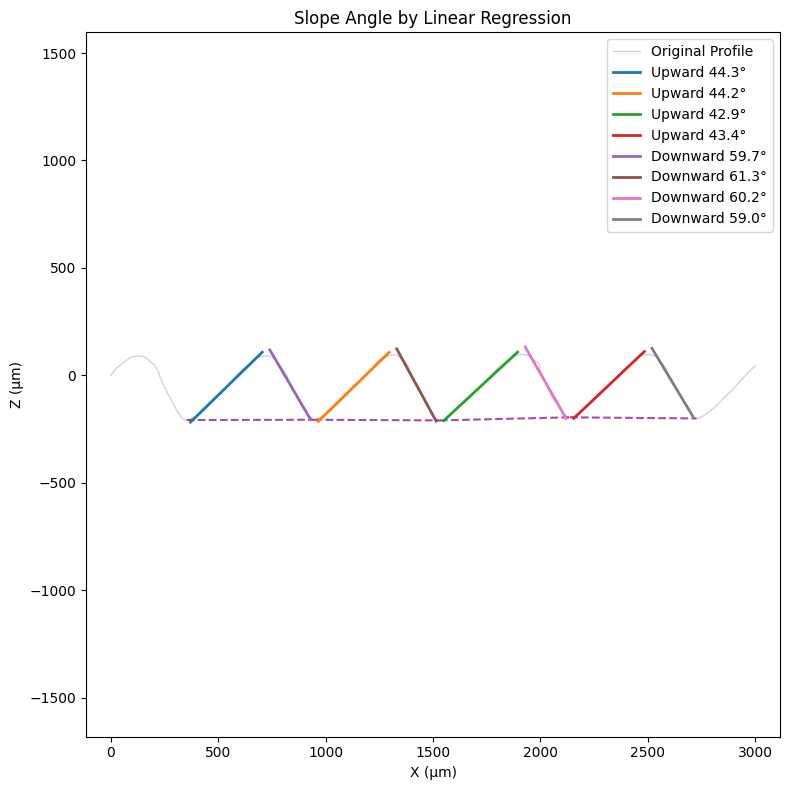

In [51]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from math import atan2, degrees, acos
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

import re

# 逐行讀檔並用正則提取每行中的兩個數值（Lateral um 和 Raw Angstrom）
data_rows = []
number_pattern = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

with open(
    r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\NEAF\20250805_06_06_07_60.csv",
    encoding="ISO-8859-1",
) as f:
    lines = f.readlines()

for line in lines[18:]:  # 從第19行開始
    numbers = re.findall(number_pattern, line)
    if len(numbers) >= 2:
        try:
            lateral = float(numbers[0])
            angstrom = float(numbers[1])
            data_rows.append((lateral, angstrom))
        except ValueError:
            continue

# 組成 DataFrame
df = pd.DataFrame(data_rows, columns=["Lateral um", "Raw Angstrom"])


# === 2. 單位轉換 ===
x = df["Lateral um"].to_numpy()  # 單位已是 μm
z = df["Raw Angstrom"].to_numpy() * 0.0001  # Å → μm
z_inv = -z  # 波峰翻轉

print("x 範圍：", x.min(), "→", x.max())
print("z 範圍：", z.min(), "→", z.max())

# === 3. 偵測波峰與波谷 ===
peaks, _ = find_peaks(z_inv, distance=400, prominence=100)
valleys, _ = find_peaks(-z_inv, distance=400, prominence=100)

# 組配對（peak → valley 或 valley → peak）
pairs = []
for p in peaks:
    v_after = valleys[valleys > p]
    if len(v_after) > 0:
        pairs.append((p, v_after[0]))
for v in valleys:
    p_after = peaks[peaks > v]
    if len(p_after) > 0:
        pairs.append((v, p_after[0]))

# === 4. 線性擬合斜邊並計算角度 ===
M = 80
angles, types, from_indices, to_indices = [], [], [], []
for idx1, idx2 in pairs:
    if idx2 - idx1 < 2 * M:
        continue
    idx1_adj = idx1 + M
    idx2_adj = idx2 - M
    x_seg = x[idx1_adj : idx2_adj + 1].reshape(-1, 1)
    z_seg = z[idx1_adj : idx2_adj + 1]
    if len(x_seg) == 0:
        continue
    reg = LinearRegression().fit(x_seg, z_seg)
    slope = reg.coef_[0]
    angle = degrees(atan2(slope, 1))
    slope_type = "Upward" if slope > 0 else "Downward"
    types.append(slope_type)
    angles.append(abs(angle))
    from_indices.append(idx1_adj)
    to_indices.append(idx2_adj)

# === 5. 組成 DataFrame ===
angle_df = pd.DataFrame(
    {"From": from_indices, "To": to_indices, "Slope Type": types, "Angle (°)": angles}
)

print("\n=== Filtered Slope Angles ===")
print(angle_df)

# === 6. 平均角度統計 ===
avg_angles = angle_df.groupby("Slope Type")["Angle (°)"].mean()
print("\n=== Average Angle by Slope Type ===")
for slope_type in avg_angles.index:
    print(f"{slope_type}: {avg_angles[slope_type]:.2f}°")

# === 7. 夾底邊角度計算 ===
base_angles = []
for idx, row in angle_df.iterrows():
    x1, z1 = x[row["From"]], z[row["From"]]
    x2, z2 = x[row["To"]], z[row["To"]]
    v1 = np.array([x2 - x1, z2 - z1])
    peak_before = peaks[peaks < row["From"]]
    peak_after = peaks[peaks > row["To"]]
    if len(peak_before) == 0 or len(peak_after) == 0:
        base_angles.append(np.nan)
        continue
    xb1, zb1 = x[peak_before[-1]], z[peak_before[-1]]
    xb2, zb2 = x[peak_after[0]], z[peak_after[0]]
    v2 = np.array([xb2 - xb1, zb2 - zb1])
    unit_v1 = v1 / np.linalg.norm(v1)
    unit_v2 = v2 / np.linalg.norm(v2)
    cos_theta = np.clip(np.dot(unit_v1, unit_v2), -1.0, 1.0)
    theta = degrees(acos(cos_theta))
    base_angles.append(theta)

angle_df["Angle w.r.t Base (°)"] = base_angles
print("\n=== Slope Angles vs Base Line ===")
print(angle_df[["Slope Type", "Angle (°)", "Angle w.r.t Base (°)"]])

# === 8. 繪圖 ===
plt.figure(figsize=(8, 8))
plt.plot(x, z, color="lightgray", linewidth=1, label="Original Profile")

# 波峰之間虛線（當作底邊）
peaks_sorted = np.sort(peaks)
for i in range(len(peaks_sorted) - 1):
    idx1, idx2 = peaks_sorted[i], peaks_sorted[i + 1]
    plt.plot(
        [x[idx1], x[idx2]],
        [z[idx1], z[idx2]],
        color="purple",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
    )

# 擬合線段繪製
for idx, row in angle_df.iterrows():
    x_fit = x[row["From"] : row["To"] + 1]
    z_fit = z[row["From"] : row["To"] + 1]
    model = LinearRegression().fit(x_fit.reshape(-1, 1), z_fit)
    z_pred = model.predict(x_fit.reshape(-1, 1))
    plt.plot(
        x_fit, z_pred, label=f'{row["Slope Type"]} {row["Angle (°)"]:.1f}°', linewidth=2
    )

plt.xlabel("X (μm)")
plt.ylabel("Z (μm)")
plt.title("Slope Angle by Linear Regression")
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.show()

## 校正基板傾斜

x 範圍： 0.0 → 2999.8
z 範圍： -209.86812999999998 → 97.89044000000001
⚙ 擬合基板斜率：-0.0462，傾角：-2.65°

=== Filtered Slope Angles ===
    From     To Slope Type  Angle (°)
0   1665   3181     Upward  46.849812
1   4343   5840     Upward  46.803939
2   6971   8541     Upward  45.434391
3   9692  11186     Upward  46.009139
4   3341   4183   Downward  57.182873
5   6000   6811   Downward  58.911799
6   8701   9532   Downward  58.008989
7  11346  12186   Downward  56.522995

=== Average Angle by Slope Type ===
Downward: 57.66°
Upward: 46.27°

=== Slope Angles vs Base Line ===
  Slope Type  Angle (°)  Angle w.r.t Base (°)
0     Upward  46.849812             40.946249
1     Upward  46.803939             41.841495
2     Upward  45.434391             39.437476
3     Upward  46.009139             41.360440
4   Downward  57.182873             56.818411
5   Downward  58.911799             58.225674
6   Downward  58.008989             58.232656
7   Downward  56.522995             56.004783


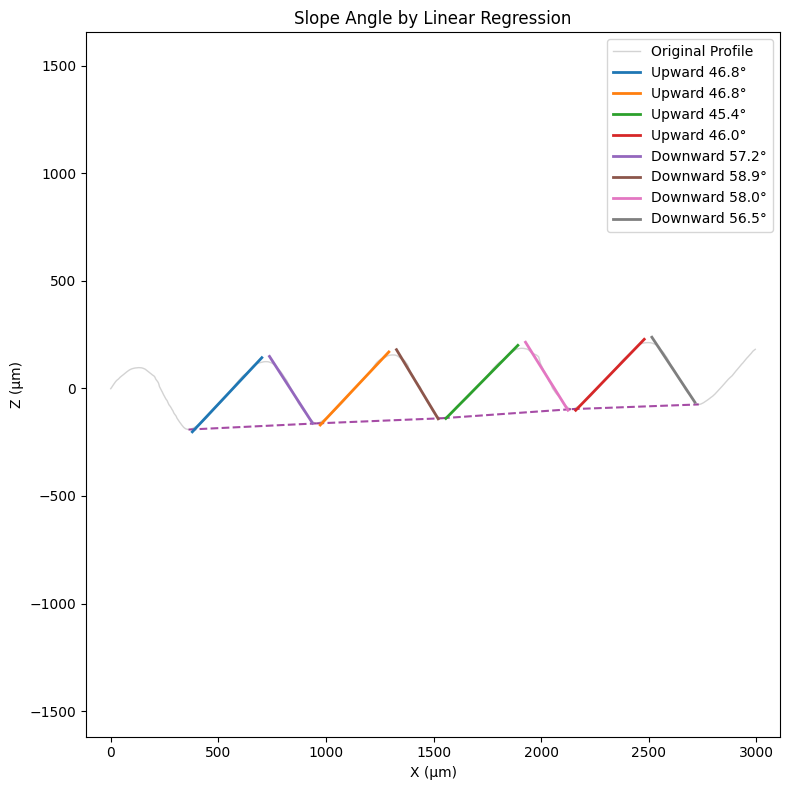

In [52]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from math import atan2, degrees, acos
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

import re

# 逐行讀檔並用正則提取每行中的兩個數值（Lateral um 和 Raw Angstrom）
data_rows = []
number_pattern = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

with open(
    r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\NEAF\20250805_06_06_07_60.csv",
    encoding="ISO-8859-1",
) as f:
    lines = f.readlines()

for line in lines[18:]:  # 從第19行開始
    numbers = re.findall(number_pattern, line)
    if len(numbers) >= 2:
        try:
            lateral = float(numbers[0])
            angstrom = float(numbers[1])
            data_rows.append((lateral, angstrom))
        except ValueError:
            continue

# 組成 DataFrame
df = pd.DataFrame(data_rows, columns=["Lateral um", "Raw Angstrom"])


# === 2. 單位轉換 ===
x = df["Lateral um"].to_numpy()  # 單位已是 μm
z = df["Raw Angstrom"].to_numpy() * 0.0001  # Å → μm
z_inv = -z  # 波峰翻轉

print("x 範圍：", x.min(), "→", x.max())
print("z 範圍：", z.min(), "→", z.max())

# === 校正基板傾斜（選擇 profile 的左右兩端 10% 範圍做線性擬合） ===
N = len(x)
left_range = slice(0, int(N * 0.1))
right_range = slice(int(N * 0.9), N)

x_base = np.concatenate([x[left_range], x[right_range]])
z_base = np.concatenate([z[left_range], z[right_range]])

reg_base = LinearRegression().fit(x_base.reshape(-1, 1), z_base)
base_slope = reg_base.coef_[0]
base_angle = degrees(atan2(base_slope, 1))
print(f"⚙ 擬合基板斜率：{base_slope:.4f}，傾角：{base_angle:.2f}°")

# 將整體 profile 做傾斜補償（旋轉坐標）
theta = atan2(base_slope, 1)
cos_t, sin_t = np.cos(-theta), np.sin(-theta)

x_rot = x * cos_t - z * sin_t
z_rot = x * sin_t + z * cos_t

# 將旋轉後的 profile 替代原本變數
x = x_rot
z = z_rot
z_inv = -z

# === 3. 偵測波峰與波谷 ===
peaks, _ = find_peaks(z_inv, distance=400, prominence=100)
valleys, _ = find_peaks(-z_inv, distance=400, prominence=100)

# 組配對（peak → valley 或 valley → peak）
pairs = []
for p in peaks:
    v_after = valleys[valleys > p]
    if len(v_after) > 0:
        pairs.append((p, v_after[0]))
for v in valleys:
    p_after = peaks[peaks > v]
    if len(p_after) > 0:
        pairs.append((v, p_after[0]))

# === 4. 線性擬合斜邊並計算角度 ===
M = 80
angles, types, from_indices, to_indices = [], [], [], []
for idx1, idx2 in pairs:
    if idx2 - idx1 < 2 * M:
        continue
    idx1_adj = idx1 + M
    idx2_adj = idx2 - M
    x_seg = x[idx1_adj : idx2_adj + 1].reshape(-1, 1)
    z_seg = z[idx1_adj : idx2_adj + 1]
    if len(x_seg) == 0:
        continue
    reg = LinearRegression().fit(x_seg, z_seg)
    slope = reg.coef_[0]
    angle = degrees(atan2(slope, 1))
    slope_type = "Upward" if slope > 0 else "Downward"
    types.append(slope_type)
    angles.append(abs(angle))
    from_indices.append(idx1_adj)
    to_indices.append(idx2_adj)

# === 5. 組成 DataFrame ===
angle_df = pd.DataFrame(
    {"From": from_indices, "To": to_indices, "Slope Type": types, "Angle (°)": angles}
)

print("\n=== Filtered Slope Angles ===")
print(angle_df)

# === 6. 平均角度統計 ===
avg_angles = angle_df.groupby("Slope Type")["Angle (°)"].mean()
print("\n=== Average Angle by Slope Type ===")
for slope_type in avg_angles.index:
    print(f"{slope_type}: {avg_angles[slope_type]:.2f}°")

# === 7. 夾底邊角度計算 ===
base_angles = []
for idx, row in angle_df.iterrows():
    x1, z1 = x[row["From"]], z[row["From"]]
    x2, z2 = x[row["To"]], z[row["To"]]
    v1 = np.array([x2 - x1, z2 - z1])
    peak_before = peaks[peaks < row["From"]]
    peak_after = peaks[peaks > row["To"]]
    if len(peak_before) == 0 or len(peak_after) == 0:
        base_angles.append(np.nan)
        continue
    xb1, zb1 = x[peak_before[-1]], z[peak_before[-1]]
    xb2, zb2 = x[peak_after[0]], z[peak_after[0]]
    v2 = np.array([xb2 - xb1, zb2 - zb1])
    unit_v1 = v1 / np.linalg.norm(v1)
    unit_v2 = v2 / np.linalg.norm(v2)
    cos_theta = np.clip(np.dot(unit_v1, unit_v2), -1.0, 1.0)
    theta = degrees(acos(cos_theta))
    base_angles.append(theta)

angle_df["Angle w.r.t Base (°)"] = base_angles
print("\n=== Slope Angles vs Base Line ===")
print(angle_df[["Slope Type", "Angle (°)", "Angle w.r.t Base (°)"]])

# === 8. 繪圖 ===
plt.figure(figsize=(8, 8))
plt.plot(x, z, color="lightgray", linewidth=1, label="Original Profile")

# 波峰之間虛線（當作底邊）
peaks_sorted = np.sort(peaks)
for i in range(len(peaks_sorted) - 1):
    idx1, idx2 = peaks_sorted[i], peaks_sorted[i + 1]
    plt.plot(
        [x[idx1], x[idx2]],
        [z[idx1], z[idx2]],
        color="purple",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
    )

# 擬合線段繪製
for idx, row in angle_df.iterrows():
    x_fit = x[row["From"] : row["To"] + 1]
    z_fit = z[row["From"] : row["To"] + 1]
    model = LinearRegression().fit(x_fit.reshape(-1, 1), z_fit)
    z_pred = model.predict(x_fit.reshape(-1, 1))
    plt.plot(
        x_fit, z_pred, label=f'{row["Slope Type"]} {row["Angle (°)"]:.1f}°', linewidth=2
    )

plt.xlabel("X (μm)")
plt.ylabel("Z (μm)")
plt.title("Slope Angle by Linear Regression")
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.show()

=== Prism Structure Widths (μm) ===
Structure 1: 944.53 μm
Structure 2: 919.54 μm
Structure 3: 919.54 μm
Structure 4: 879.56 μm
Structure 5: 869.57 μm
Structure 6: 874.56 μm
Structure 7: 969.52 μm
Structure 8: 884.56 μm
Structure 9: 874.56 μm
Structure 10: 909.55 μm
Structure 11: 914.54 μm
Structure 12: 909.55 μm
Structure 13: 889.56 μm
Structure 14: 909.55 μm
Structure 15: 889.56 μm
Structure 16: 889.56 μm
Structure 17: 939.53 μm
Structure 18: 879.56 μm
Structure 19: 949.53 μm
Structure 20: 879.56 μm
Structure 21: 879.56 μm

=== Filtered Slope Angles ===
   From    To Slope Type  Angle (°)
0  1497  1508     Upward  15.998257

=== Average Angle by Slope Type ===
Upward: 16.00°


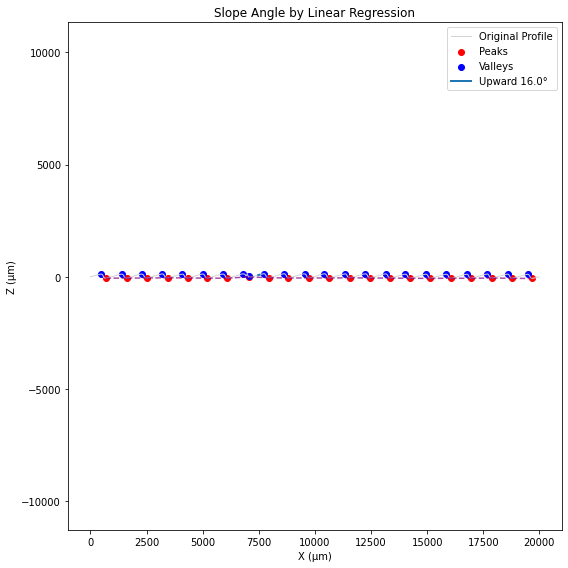


=== Slope Angles vs Base Line ===
  Slope Type  Angle (°)  Angle w.r.t Base (°)
0     Upward  15.998257             18.084612


In [1]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks, savgol_filter
from math import atan2, degrees
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# === 載入資料 ===
df = pd.read_excel(
    r"C:\Users\cchih\Desktop\NTHU\MasterThesis\research_log\202508\harper\excel\20250804_0.9_0.3_90_02.xlsx",
    sheet_name="01",
)

# === 單位轉換 ===
x = df["X(mm)"].to_numpy() * 1000  # mm → μm
z = df["Z(nm)"].to_numpy() * 0.001  # nm → μm

# === 平滑化曲線 ===
z_smooth = savgol_filter(z, window_length=15, polyorder=3)
z_inv = -z_smooth

# === 自動調整 peak 偵測參數 ===
x_spacing = np.median(np.diff(x))  # μm/pt
distance_pts = int(250 / x_spacing)  # 預期結構的一半寬度（單位：index）
prominence_val = (np.max(z_smooth) - np.min(z_smooth)) * 0.05

peaks, _ = find_peaks(z_inv, distance=distance_pts, prominence=prominence_val)
valleys, _ = find_peaks(-z_inv, distance=distance_pts, prominence=prominence_val)

# === 如果找不到足夠的峰，提醒使用者 ===
if len(peaks) < 2:
    print("⚠️ 警告：偵測到的三角形波峰數量過少（可能結構邊長太短）")

# === 計算稜鏡寬度 ===
widths = np.diff(x[peaks])
print("=== Prism Structure Widths (μm) ===")
for i, w in enumerate(widths):
    if w > 500:  # 過濾合理寬度
        print(f"Structure {i+1}: {w:.2f} μm")

# === 建立 peak→valley 與 valley→peak 對 ===
pairs = []
for p in peaks:
    v_after = valleys[valleys > p]
    if len(v_after) > 0:
        pairs.append((p, v_after[0]))

for v in valleys:
    p_after = peaks[peaks > v]
    if len(p_after) > 0:
        pairs.append((v, p_after[0]))

# === 擬合每對邊並計算角度 ===
M = 80  # 往內縮的點數
angles, types, from_indices, to_indices = [], [], [], []
for idx1, idx2 in pairs:
    if idx2 - idx1 < 2 * M:
        continue

    idx1_adj = idx1 + M
    idx2_adj = idx2 - M

    x_seg = x[idx1_adj : idx2_adj + 1].reshape(-1, 1)
    z_seg = z[idx1_adj : idx2_adj + 1]  # 用原始 z 擬合

    if len(x_seg) == 0:
        continue

    reg = LinearRegression().fit(x_seg, z_seg)
    slope = reg.coef_[0]
    angle = degrees(atan2(slope, 1))

    slope_type = "Upward" if slope > 0 else "Downward"

    types.append(slope_type)
    angles.append(abs(angle))
    from_indices.append(idx1_adj)
    to_indices.append(idx2_adj)

# === 整理成資料表 ===
angle_df = pd.DataFrame(
    {"From": from_indices, "To": to_indices, "Slope Type": types, "Angle (°)": angles}
)

print("\n=== Filtered Slope Angles ===")
print(angle_df)

# === 平均角度統計 ===
avg_angles = angle_df.groupby("Slope Type")["Angle (°)"].mean()
print("\n=== Average Angle by Slope Type ===")
for slope_type in avg_angles.index:
    print(f"{slope_type}: {avg_angles[slope_type]:.2f}°")

# === 畫圖：原始資料與擬合線、peaks/valleys ===
plt.figure(figsize=(8, 8))
plt.plot(x, z, color="lightgray", linewidth=1, label="Original Profile")

# 標記 peaks 和 valleys
plt.scatter(x[peaks], z[peaks], color="red", label="Peaks")
plt.scatter(x[valleys], z[valleys], color="blue", label="Valleys")

# 底邊（峰對峰）
peaks_sorted = np.sort(peaks)
for i in range(len(peaks_sorted) - 1):
    idx1, idx2 = peaks_sorted[i], peaks_sorted[i + 1]
    plt.plot(
        [x[idx1], x[idx2]],
        [z[idx1], z[idx2]],
        color="purple",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
    )

# 擬合線段
for idx, row in angle_df.iterrows():
    x_fit = x[row["From"] : row["To"] + 1]
    z_fit = z[row["From"] : row["To"] + 1]
    model = LinearRegression().fit(x_fit.reshape(-1, 1), z_fit)
    z_pred = model.predict(x_fit.reshape(-1, 1))
    plt.plot(
        x_fit, z_pred, label=f'{row["Slope Type"]} {row["Angle (°)"]:.1f}°', linewidth=2
    )

plt.xlabel("X (μm)")
plt.ylabel("Z (μm)")
plt.title("Slope Angle by Linear Regression")
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.show()

# === 夾角計算：斜邊對底邊 ===
base_angles = []
for idx, row in angle_df.iterrows():
    x1, z1 = x[row["From"]], z[row["From"]]
    x2, z2 = x[row["To"]], z[row["To"]]
    v1 = np.array([x2 - x1, z2 - z1])

    peak_before = peaks[peaks < row["From"]]
    peak_after = peaks[peaks > row["To"]]
    if len(peak_before) == 0 or len(peak_after) == 0:
        base_angles.append(np.nan)
        continue

    idx_p1 = peak_before[-1]
    idx_p2 = peak_after[0]
    xb1, zb1 = x[idx_p1], z[idx_p1]
    xb2, zb2 = x[idx_p2], z[idx_p2]
    v2 = np.array([xb2 - xb1, zb2 - zb1])

    unit_v1 = v1 / np.linalg.norm(v1)
    unit_v2 = v2 / np.linalg.norm(v2)
    cos_theta = np.clip(np.dot(unit_v1, unit_v2), -1.0, 1.0)
    theta = degrees(np.arccos(cos_theta))

    base_angles.append(theta)

angle_df["Angle w.r.t Base (°)"] = base_angles

print("\n=== Slope Angles vs Base Line ===")
print(angle_df[["Slope Type", "Angle (°)", "Angle w.r.t Base (°)"]])